In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import SurvivalToDischarge

C:\Users\redja\AppData\Local\Temp\ipykernel_11832\3430672329.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Data

In [2]:
X, y = SurvivalToDischarge.load_data(sample_size=100000, icu_vitals=True, top_n_labs=200, top_n_drugs=200, top_n_procedures=200)

Returing 100000 patient records with 542 columns. y distribution: 
hospital_expire_flag
0    0.97966
1    0.02034
Name: proportion, dtype: float64


In [3]:
# 80/20 train-test, need to switch to train-validate-test once were comparing models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 542), Test: (20000, 542)


In [8]:
X.head(20)

,los_hours,anchor_age,gender_female,meanbp_systolic,meanbp_diastolic,maxbp_systolic,maxbp_diastolic,minbp_systolic,minbp_diastolic,result_value_x,...,admission_location_WALK-IN/SELF REFERRAL,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_BLACK,race_HISPANIC/LATINO,race_NATIVE AMERICAN/ALASKA NATIVE,race_UNKNOWN OR MULTIPLE,race_WHITE
0,135.316667,47,1,127.833333,73.250000,152.0,89.0,104.0,59.0,126.000000,...,1,0,0,0,1,0,0,0,0,1
1,92.466667,59,1,123.177778,74.888889,151.0,93.0,80.0,52.0,166.219512,...,0,0,0,0,1,1,0,0,0,0
2,89.916667,76,0,149.833333,59.500000,177.0,68.0,113.0,50.0,157.715000,...,0,1,0,0,0,0,0,0,0,1
3,5.266667,31,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,0,0,0,1,0,0,0
4,25.466667,74,1,145.500000,59.500000,176.0,80.0,122.0,36.0,148.657895,...,0,1,0,0,0,0,0,0,0,1
5,9.433333,47,0,127.833333,73.250000,152.0,89.0,104.0,59.0,171.700000,...,0,0,0,1,0,0,1,0,0,0
6,15.533333,62,1,121.800000,69.200000,138.0,71.0,113.0,67.0,171.700000,...,0,0,0,0,1,0,0,0,0,1
7,78.033333,31,1,114.000000,70.750000,120.0,80.0,108.0,60.0,171.700000,...,0,0,0,0,1,1,0,0,0,0
8,60.633333,89,1,155.701754,68.719298,214.0,90.0,104.0,47.0,160.765455,...,0,1,0,0,0,0,0,0,0,1
9,62.233333,48,1,112.000000,78.200000,128.0,84.0,104.0,74.0,171.700000,...,0,0,0,0,1,0,0,0,1,0


## Logistic Regression (no scaling/class weighting)

In [ ]:
# This takes like 20 minutes to do without scaling.
model = LogisticRegression(C=0.2, max_iter=100000, solver='saga')
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

C:\Users\redja\AppData\Local\Temp\ipykernel_9416\708429039.py:10: RuntimeWarning: invalid value encountered in scalar divide
  ppv = tp / (tp + fp)   # precision
c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricW

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       19593        0   (specificity 1.000)
  Actual 1         407        0   (sensitivity 0.000)

TPR (sensitivity):  0.000
FPR (fall-out):     0.000
Precision:          nan
ROC-AUC:            0.453

              precision    recall  f1-score   support

    Survived       0.98      1.00      0.99     19593
        Died       0.00      0.00      0.00       407

    accuracy                           0.98     20000
   macro avg       0.49      0.50      0.49     20000
weighted avg       0.96      0.98      0.97     20000



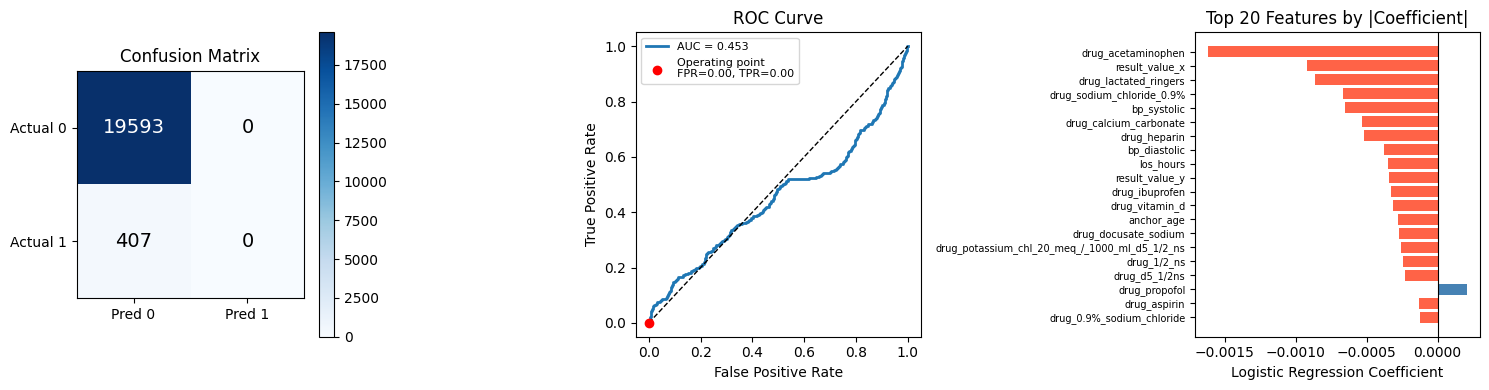

In [ ]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top_coef = coef_series[coef_series != 0].abs().sort_values(ascending=False).head(20)
signed_top = coef_series[top_coef.index]
colors = ['steelblue' if v > 0 else 'tomato' for v in signed_top]
axes[2].barh(signed_top.index[::-1], signed_top.values[::-1], color=colors[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Logistic Regression Coefficient')
axes[2].set_title('Top 20 Features by |Coefficient|')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

## Logistic Regression (scaled and class weighted)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [5]:
model = LogisticRegression(C=0.2, class_weight='balanced', max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.2
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18699      894   (specificity 0.954)
  Actual 1          38      369   (sensitivity 0.907)

TPR (sensitivity):  0.907
FPR (fall-out):     0.046
Precision:          0.292
ROC-AUC:            0.969

              precision    recall  f1-score   support

    Survived       1.00      0.95      0.98     19593
        Died       0.29      0.91      0.44       407

    accuracy                           0.95     20000
   macro avg       0.65      0.93      0.71     20000
weighted avg       0.98      0.95      0.96     20000



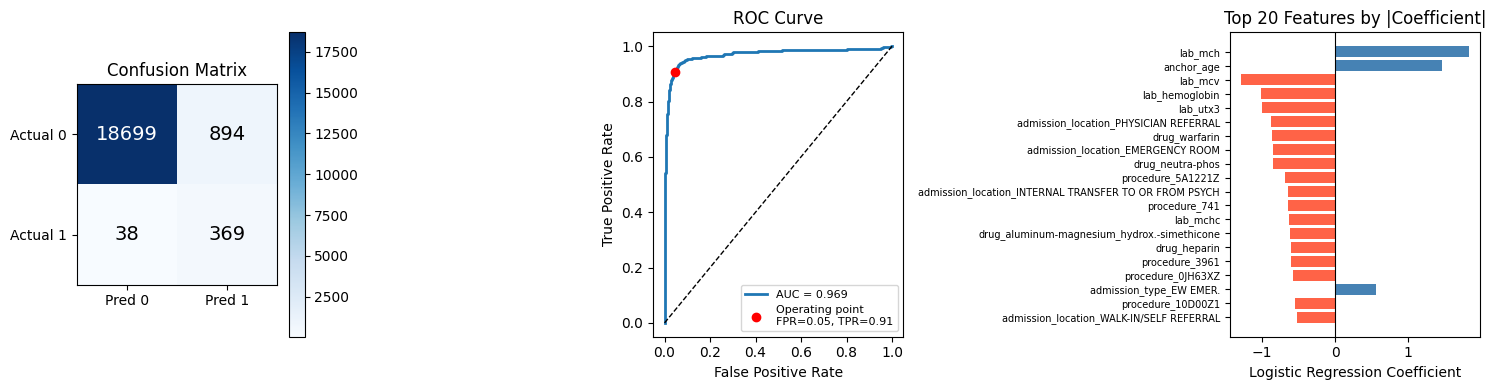

In [6]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top_coef = coef_series[coef_series != 0].abs().sort_values(ascending=False).head(20)
signed_top = coef_series[top_coef.index]
colors = ['steelblue' if v > 0 else 'tomato' for v in signed_top]
axes[2].barh(signed_top.index[::-1], signed_top.values[::-1], color=colors[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Logistic Regression Coefficient')
axes[2].set_title('Top 20 Features by |Coefficient|')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
#plt.savefig('results/logistic_regression_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# Logistic regression with L1 penalty and 20 different regularization strengths
model = LogisticRegressionCV(
    Cs=np.logspace(-4, 1, 20),
    cv=5,
    l1_ratios=(1,),
    solver='saga',
    max_iter=800,
    tol=1e-4,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

best_C = model.C_[0]
print(f"Best C: {best_C:.6f}")
print(f"Non-zero coefficients: {np.sum(model.coef_[0] != 0)} / {len(model.coef_[0])}")

c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


convergence after 47 epochs took 29 seconds
convergence after 48 epochs took 30 seconds
convergence after 49 epochs took 31 seconds
convergence after 50 epochs took 32 seconds
convergence after 49 epochs took 32 seconds
convergence after 75 epochs took 48 seconds
convergence after 78 epochs took 50 seconds
convergence after 76 epochs took 48 seconds
convergence after 75 epochs took 47 seconds
convergence after 75 epochs took 48 seconds
convergence after 104 epochs took 66 seconds
convergence after 103 epochs took 65 seconds
convergence after 133 epochs took 85 seconds
convergence after 169 epochs took 108 seconds
convergence after 211 epochs took 135 seconds
max_iter reached after 502 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 505 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 518 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 261 epochs took 169 seconds
max_iter reached after 507 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 234 epochs took 153 seconds
convergence after 316 epochs took 213 seconds
convergence after 410 epochs took 257 seconds
max_iter reached after 500 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 510 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 396 epochs took 266 seconds
convergence after 223 epochs took 142 seconds
max_iter reached after 502 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 269 epochs took 172 seconds
convergence after 323 epochs took 206 seconds
convergence after 319 epochs took 210 seconds
max_iter reached after 496 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 511 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 478 epochs took 310 seconds
convergence after 800 epochs took 565 seconds
max_iter reached after 565 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 209 epochs took 132 seconds
convergence after 215 epochs took 142 seconds
convergence after 400 epochs took 269 seconds
convergence after 248 epochs took 166 seconds
convergence after 331 epochs took 219 seconds
convergence after 265 epochs took 175 seconds
convergence after 392 epochs took 258 seconds
convergence after 337 epochs took 225 seconds
max_iter reached after 555 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 782 epochs took 528 seconds
convergence after 735 epochs took 502 seconds
convergence after 394 epochs took 271 seconds
convergence after 544 epochs took 364 seconds
max_iter reached after 565 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 738 epochs took 514 seconds
max_iter reached after 551 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 558 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 547 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 717 epochs took 568 seconds
max_iter reached after 666 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 768 epochs took 638 seconds
max_iter reached after 683 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 778 epochs took 666 seconds
convergence after 536 epochs took 490 seconds
max_iter reached after 724 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 300 epochs took 286 seconds
convergence after 763 epochs took 697 seconds
convergence after 644 epochs took 591 seconds
convergence after 767 epochs took 711 seconds
convergence after 243 epochs took 228 seconds
convergence after 244 epochs took 233 seconds
convergence after 429 epochs took 406 seconds
max_iter reached after 748 seconds
convergence after 594 epochs took 568 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 260 epochs took 255 seconds
max_iter reached after 758 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 531 epochs took 503 seconds
max_iter reached after 762 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 747 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 752 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 749 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 746 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 736 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 727 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 768 epochs took 709 seconds
max_iter reached after 739 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 320 epochs took 298 seconds
max_iter reached after 734 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 179 epochs took 155 seconds
max_iter reached after 712 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 691 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


convergence after 633 epochs took 552 seconds
convergence after 290 epochs took 232 seconds
convergence after 162 epochs took 132 seconds


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 123.3min remaining: 185.0min


max_iter reached after 621 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 598 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 594 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 523 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 509 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 525 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 520 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 506 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 522 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 501 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


max_iter reached after 470 seconds


c:\Users\redja\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 151.4min finished


convergence after 155 epochs took 76 seconds
Best C: 0.003793
Non-zero coefficients: 232 / 542


In [9]:
import joblib
joblib.dump(model, 'results/lasso_model.joblib')

['results/lasso_model.joblib']

In [10]:
coef_series = pd.Series(model.coef_[0], index=X.columns)
coef_series = coef_series.sort_values()
coef_series.to_csv('results/coef_series.csv')

Confusion matrix:
                Pred 0   Pred 1
  Actual 0       18625      968   (specificity 0.951)
  Actual 1          27      380   (sensitivity 0.934)

TPR (sensitivity):  0.934
FPR (fall-out):     0.049
Precision:          0.282
ROC-AUC:            0.984

              precision    recall  f1-score   support

    Survived       1.00      0.95      0.97     19593
        Died       0.28      0.93      0.43       407

    accuracy                           0.95     20000
   macro avg       0.64      0.94      0.70     20000
weighted avg       0.98      0.95      0.96     20000



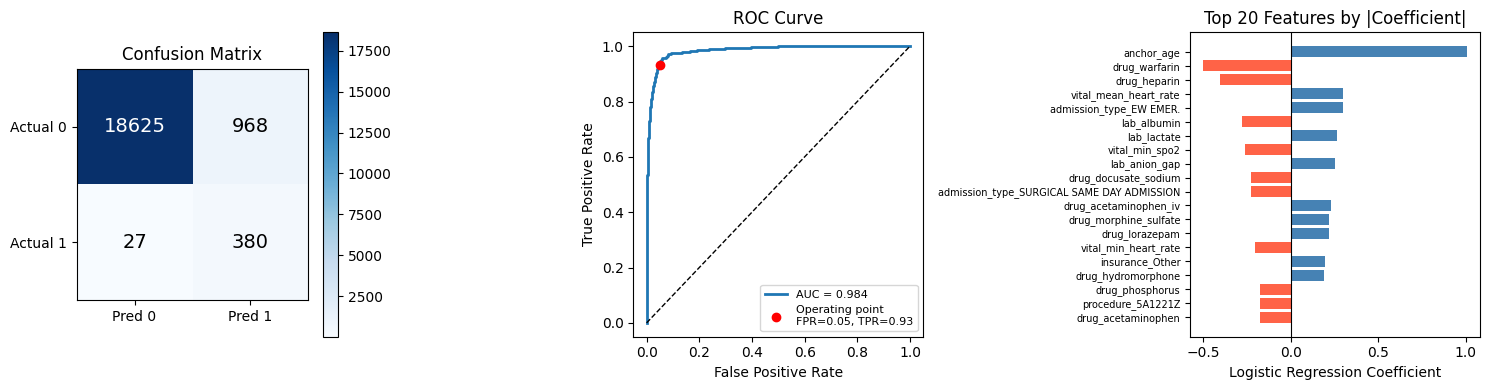

In [11]:
y_pred  = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
tpr = tp / (tp + fn)   # sensitivity / recall
fpr = fp / (fp + tn)   # fall-out
tnr = tn / (tn + fp)   # specificity
ppv = tp / (tp + fp)   # precision

print("Confusion matrix:")
print(f"  {'':12s}  Pred 0   Pred 1")
print(f"  {'Actual 0':12s}  {tn:>6}   {fp:>6}   (specificity {tnr:.3f})")
print(f"  {'Actual 1':12s}  {fn:>6}   {tp:>6}   (sensitivity {tpr:.3f})")
print()
print(f"TPR (sensitivity):  {tpr:.3f}")
print(f"FPR (fall-out):     {fpr:.3f}")
print(f"Precision:          {ppv:.3f}")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_proba):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix heatmap
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
axes[0].set_yticklabels(['Actual 0', 'Actual 1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
axes[0].set_title('Confusion Matrix')
plt.colorbar(im, ax=axes[0])

# ROC curve
fpr_curve, tpr_curve, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr_curve, tpr_curve, lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].scatter([fpr], [tpr], color='red', zorder=5, label=f'Operating point\nFPR={fpr:.2f}, TPR={tpr:.2f}')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend(fontsize=8)

# Top feature coefficients
coef_series = pd.Series(model.coef_[0], index=X.columns)
top_coef = coef_series[coef_series != 0].abs().sort_values(ascending=False).head(20)
signed_top = coef_series[top_coef.index]
colors = ['steelblue' if v > 0 else 'tomato' for v in signed_top]
axes[2].barh(signed_top.index[::-1], signed_top.values[::-1], color=colors[::-1])
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_xlabel('Logistic Regression Coefficient')
axes[2].set_title('Top 20 Features by |Coefficient|')
axes[2].tick_params(axis='y', labelsize=7)

plt.tight_layout()
#plt.savefig('results/lasso_results.png', dpi=120, bbox_inches='tight')
plt.show()